In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
customers = pd.read_csv("data/csv/customers.csv")
orders = pd.read_csv("data/csv/orders.csv")
products = pd.read_csv("data/csv/products.csv")
support_tickets = pd.read_csv("data/csv/support_tickets.csv")
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Support Tickets:", support_tickets.shape)

Customers: (862, 12)
Orders: (3388, 10)
Products: (15, 6)
Support Tickets: (520, 8)


Station B — Python cleaning and EDA

Inspect the data

In [ ]:
print("CUSTOMERS")
print(customers.info())

print("\nORDERS")
print(orders.info())

print("\nPRODUCTS")
print(products.info())

print("\nSUPPORT TICKETS")
print(support_tickets.info())

CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       862 non-null    int64  
 1   first_name        862 non-null    str    
 2   last_name         862 non-null    str    
 3   email             862 non-null    str    
 4   phone             845 non-null    str    
 5   city              862 non-null    str    
 6   state             862 non-null    str    
 7   signup_date       862 non-null    str    
 8   plan              862 non-null    str    
 9   age               835 non-null    float64
 10  last_active_date  862 non-null    str    
 11  churned           862 non-null    int64  
dtypes: float64(1), int64(2), str(9)
memory usage: 80.9 KB
None

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 3388 entries, 0 to 3387
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------

Check Missing Values

In [ ]:
print("Missing values in Customers:")
print(customers.isnull().sum())

print("\nMissing values in Orders:")
print(orders.isnull().sum())

print("\nMissing values in Products:")
print(products.isnull().sum())

print("\nMissing values in Support Tickets:")
print(support_tickets.isnull().sum())

Missing values in Customers:
customer_id          0
first_name           0
last_name            0
email                0
phone               17
city                 0
state                0
signup_date          0
plan                 0
age                 27
last_active_date     0
churned              0
dtype: int64

Missing values in Orders:
order_id        0
customer_id     0
product_id      0
order_date      0
channel         0
quantity        0
unit_price      0
discount_pct    0
returned        0
status          0
dtype: int64

Missing values in Products:
product_id      0
sku             0
product_name    0
category        0
unit_cost       0
list_price      0
dtype: int64

Missing values in Support Tickets:
ticket_id       0
customer_id     0
order_id        0
created_at      0
ticket_type    31
priority        0
raw_message     0
resolved        0
dtype: int64


Check Duplicate Records

In [ ]:
# Check duplicate rows
print("Duplicate rows in Customers:", customers.duplicated().sum())
print("Duplicate rows in Orders:", orders.duplicated().sum())

print("Duplicate rows in Products:", products.duplicated().sum())
print("Duplicate rows in Support Tickets:", support_tickets.duplicated().sum())

Duplicate rows in Customers: 0
Duplicate rows in Orders: 0
Duplicate rows in Products: 0
Duplicate rows in Support Tickets: 0


In [ ]:
# Check for invalid email formats
email_pattern = r'^[^@\s]+@[^@\s]+\.[^@\s]+$'
invalid_emails = customers[~customers["email"].str.match(email_pattern, na=False)]
print("Invalid email records:", len(invalid_emails))
print(invalid_emails[["customer_id", "email"]].head(20))

Invalid email records: 20
     customer_id                         email
40         10041      noahsilva41 at gmail.com
81         10082   hannahnguyen82 at gmail.com
122        10123    ryanwalker123 at gmail.com
163        10164      ethankim164 at gmail.com
204        10205   imanibrooks205 at gmail.com
245        10246    gracereyes246 at gmail.com
286        10287  hannahnguyen287 at gmail.com
327        10328    noahfoster328 at gmail.com
368        10369    chrispatel369 at gmail.com
409        10410    diegopatel410 at gmail.com
450        10451    ryanfoster451 at gmail.com
491        10492     ethanshah492 at gmail.com
532        10533   elenamorgan533 at gmail.com
573        10574     miawalker574 at gmail.com
614        10615    liamhughes615 at gmail.com
655        10656   imanibrooks656 at gmail.com
696        10697     diegokhan697 at gmail.com
737        10738    fatimashah738 at gmail.com
778        10779   chrisbrooks779 at gmail.com
819        10820   chrisfoster820 

In [8]:
# Fix the obvious " at " email formatting issue
customers["email"] = customers["email"].str.replace(" at ", "@", regex=False)
invalid_emails_after = customers[~customers["email"].str.match(email_pattern, na=False)]
print("Invalid emails after cleaning:", len(invalid_emails_after))

Invalid emails after cleaning: 0


In [9]:
# Check phone number format
phone_pattern = r'^\+?[0-9\s\-\(\)]{10,15}$'
invalid_phones = customers[
    customers["phone"].notna() &
    ~customers["phone"].str.match(phone_pattern, na=False)]
print("Missing phone numbers:", customers["phone"].isna().sum())
print("Invalid phone numbers:", len(invalid_phones))
print("\nExamples of invalid phone numbers:")
print(invalid_phones[["customer_id", "phone"]].head(20))

Missing phone numbers: 17
Invalid phone numbers: 0

Examples of invalid phone numbers:
Empty DataFrame
Columns: [customer_id, phone]
Index: []


In [11]:
# Find duplicate customer emails
duplicate_emails = (
    customers[customers["email"].duplicated(keep=False)]
    .sort_values("email"))
print("Customers involved in duplicate emails:", len(duplicate_emails))
print("\nDuplicate email records:")
print(duplicate_emails[["customer_id", "first_name", "last_name", "email"]].to_string(index=False))

Customers involved in duplicate emails: 24

Duplicate email records:
 customer_id first_name last_name                              email
       10136      Amara    Nguyen amara.nguyen136@pulsecart-mail.com
       20011      amara    Nguyen amara.nguyen136@pulsecart-mail.com
       20002      arjun       Ali             arjun.ali684@gmail.com
       10684      Arjun       Ali             arjun.ali684@gmail.com
       20001      diego    Foster          diego.foster827@gmail.com
       10827      Diego    Foster          diego.foster827@gmail.com
       20010      grace     Reyes         grace.reyes580@outlook.com
       10580      Grace     Reyes         grace.reyes580@outlook.com
       20007        leo       Rao               leo.rao325@yahoo.com
       10325        Leo       Rao               leo.rao325@yahoo.com
       20003       nina    Morgan         nina.morgan307@outlook.com
       10307       Nina    Morgan         nina.morgan307@outlook.com
       20012      priya     Reyes 

In [12]:
# Keep the customer with the lower customer_id when the same email appears more than once.
customers_clean = (customers
    .sort_values("customer_id")
    .drop_duplicates(subset="email", keep="first")
    .copy()
)
print("Original customer records:", len(customers))
print("Customer records after deduplication:", len(customers_clean))
print("Duplicate records removed from analysis:",len(customers) - len(customers_clean))

Original customer records: 862
Customer records after deduplication: 850
Duplicate records removed from analysis: 12


Check orphon orders

In [13]:
# Find orders whose customer_id does not exist in the original customer dataset.
orphan_orders = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
].copy()
print("Orphan orders:", len(orphan_orders))
print("\nSample orphan orders:")
print(orphan_orders[["order_id", "customer_id", "product_id", "order_date"] ].head(20).to_string(index=False))

Orphan orders: 25

Sample orphan orders:
 order_id  customer_id  product_id order_date
    90001        39999        1011 2025-01-30
    90002        39999        1015 2025-07-16
    90003        39999        1002 2025-12-14
    90004        39999        1006 2025-08-29
    90005        39999        1013 2026-03-12
    90006        39999        1011 2026-02-14
    90007        39999        1010 2025-10-09
    90008        39999        1004 2026-05-24
    90009        39999        1011 2026-03-18
    90010        39999        1008 2025-04-02
    90011        39999        1013 2026-04-07
    90012        39999        1010 2026-03-17
    90013        39999        1014 2025-07-01
    90014        39999        1011 2025-06-23
    90015        39999        1004 2025-05-04
    90016        39999        1007 2026-02-19
    90017        39999        1015 2026-01-03
    90018        39999        1012 2026-07-08
    90019        39999        1002 2026-07-29
    90020        39999        1014 2025

In [14]:
# Keep only orders linked to the cleaned customer data
orders_clean = orders[
    orders["customer_id"].isin(customers_clean["customer_id"])
].copy()
print("Original orders:", len(orders))
print("Orphan orders:", len(orphan_orders))
print("Orders after cleaning:", len(orders_clean))

Original orders: 3388
Orphan orders: 25
Orders after cleaning: 3363


In [18]:
# Calculate churn rate by city
city_churn = (
    customers_clean
    .groupby("city")
    .agg(total_customers=("customer_id", "count"), churned_customers=("churned", "sum") )
    .reset_index())

city_churn["churn_rate"] = (
    city_churn["churned_customers"]
    / city_churn["total_customers"]
    * 100)

city_churn = city_churn.sort_values("churn_rate", ascending=False)
print(city_churn)

      city  total_customers  churned_customers  churn_rate
6  Houston              188                 57   30.319149
9  Seattle               60                 10   16.666667
3  Chicago              106                 17   16.037736
4   Dallas              120                 17   14.166667
0  Atlanta               82                 10   12.195122
7    Miami               45                  5   11.111111
8  Phoenix               56                  6   10.714286
1   Austin               94                 10   10.638298
2   Boston               40                  4   10.000000
5   Denver               59                  5    8.474576


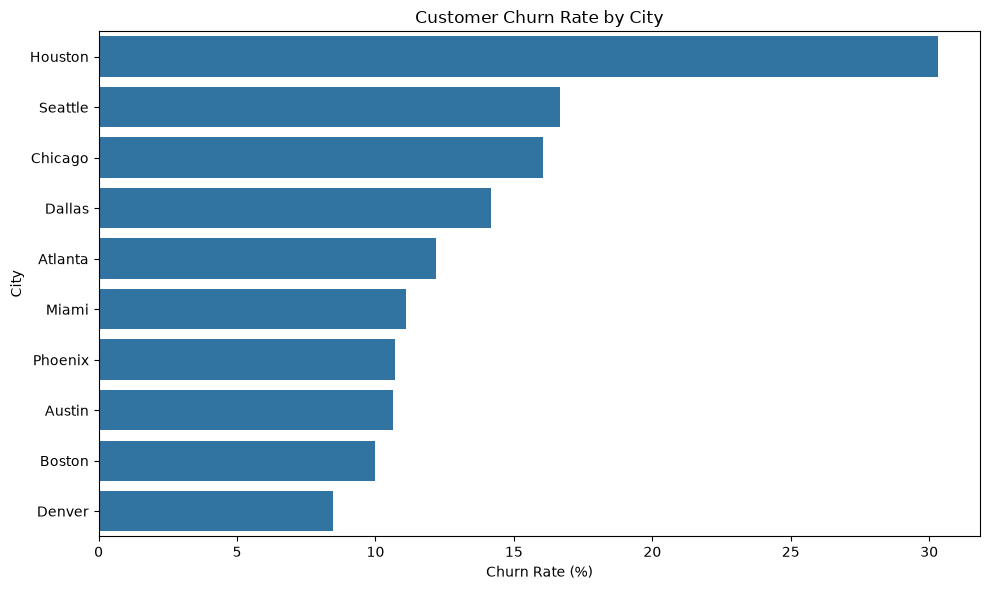

In [23]:
# Plot churn rate by city
plt.figure(figsize=(10, 6))
sns.barplot(data=city_churn, x="churn_rate", y="city")
plt.title("Customer Churn Rate by City")
plt.xlabel("Churn Rate (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

### What the city churn chart tells us

Houston has the highest observed churn rate at about 30.3%, while the other cities are below 17%.

This does not prove that location causes churn, but it gives us a clear city-level difference to investigate further in the statistics and modeling stations.

In [21]:
# Calculate return rate by product category
category_returns = (
    orders_clean
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category")
    .agg(total_orders=("order_id", "count"), returned_orders=("returned", "sum"))
    .reset_index())

category_returns["return_rate"] = (
    category_returns["returned_orders"]
    / category_returns["total_orders"]
    * 100
)

category_returns = category_returns.sort_values("return_rate", ascending=False)
print(category_returns)

      category  total_orders  returned_orders  return_rate
3      Kitchen           713              170    23.842917
2         Home           650               52     8.000000
4    Wearables           683               54     7.906296
1        Audio           644               36     5.590062
0  Accessories           673               30     4.457652


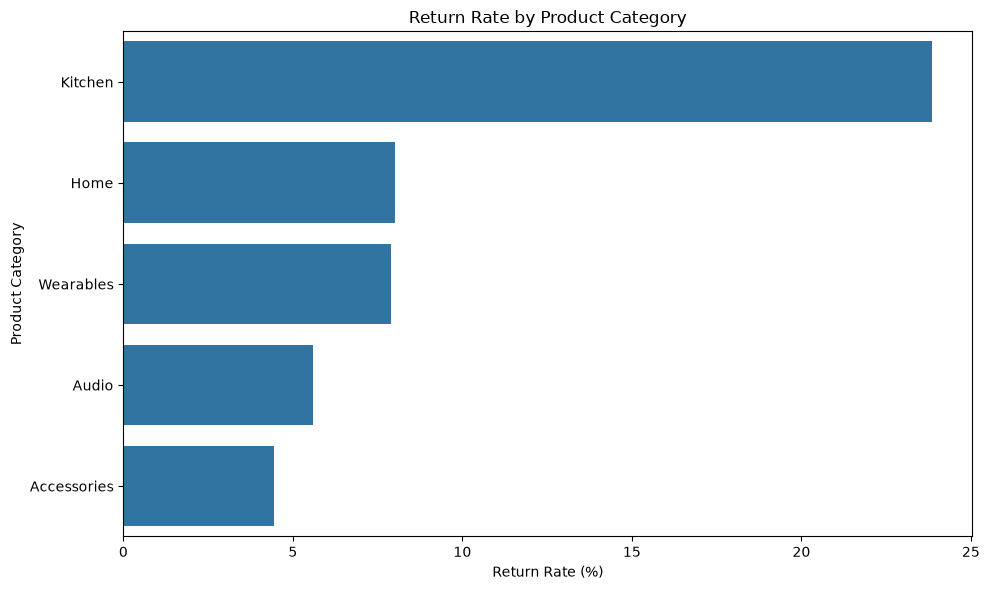

In [22]:
# Plot return rate by product category
plt.figure(figsize=(10, 6))
sns.barplot(data=category_returns, x="return_rate", y="category")
plt.title("Return Rate by Product Category")
plt.xlabel("Return Rate (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### What the category return chart tells us

Kitchen has the highest observed return rate at about 23.8%, while the other categories are below 8%.

This makes Kitchen a useful category to investigate further, especially at the product level. The later statistical test will check whether this difference is large enough to treat as evidence rather than just a sample difference.

In [24]:
# Check product price statistics
print(products["list_price"].describe())

count     15.000000
mean      78.066667
std       52.258242
min       15.000000
25%       36.500000
50%       69.000000
75%      104.000000
max      199.000000
Name: list_price, dtype: float64


In [25]:
# Detect price outliers using the IQR method
Q1 = products["list_price"].quantile(0.25)
Q3 = products["list_price"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
price_outliers = products[(products["list_price"] < lower_limit) | (products["list_price"] > upper_limit)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

print("\nPotential price outliers:")
print(price_outliers[["product_id", "product_name", "category", "list_price"]].to_string(index=False))
print("\nNumber of potential outliers:", len(price_outliers))

Q1: 36.5
Q3: 104.0
IQR: 67.5
Lower limit: -64.75
Upper limit: 205.25

Potential price outliers:
Empty DataFrame
Columns: [product_id, product_name, category, list_price]
Index: []

Number of potential outliers: 0


In [27]:
# Check if any product has a unit cost higher than its list price
impossible_prices = products[products["unit_cost"] > products["list_price"]]
print("Products with unit cost greater than list price:", len(impossible_prices))
print(impossible_prices[["product_id", "product_name", "unit_cost", "list_price"]].to_string(index=False))

Products with unit cost greater than list price: 0
Empty DataFrame
Columns: [product_id, product_name, unit_cost, list_price]
Index: []


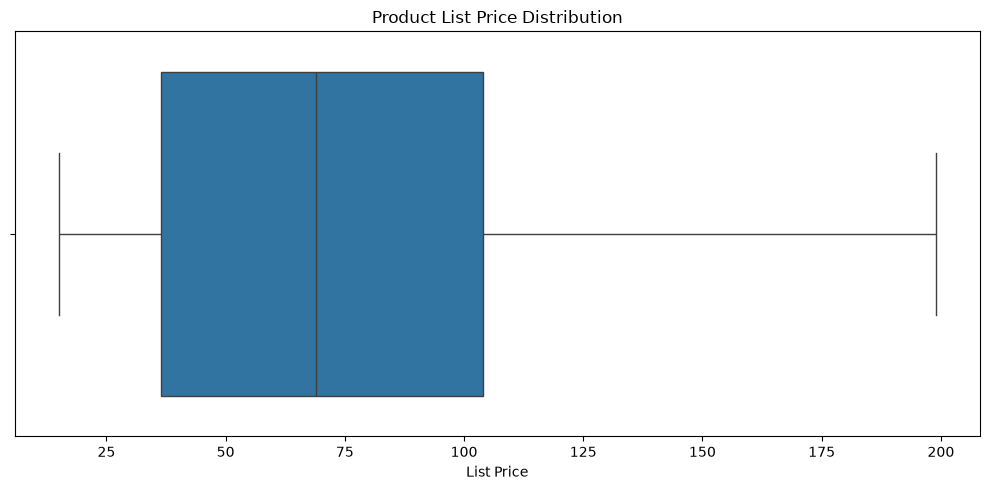

In [30]:
# Check product price distribution and possible outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=products, x="list_price")
plt.title("Product List Price Distribution")
plt.xlabel("List Price")
plt.tight_layout()
plt.show()

### What the price plot tells us

The product prices range from $15 to $199.

Using the 1.5 × IQR rule, no statistical price outliers were detected, so there is no reason to remove a product based on price alone.

The separate business-rule check above is used to catch prices that may be impossible even if they are not statistical outliers.

Station C — Statistics

Order Value — Center and Spread

In [31]:
orders_clean["order_value"] = (orders_clean["quantity"] * orders_clean["unit_price"] * (1 - orders_clean["discount_pct"] / 100))
print("Order value summary:")
print(orders_clean["order_value"].describe())

Order value summary:
count    3363.000000
mean       89.626509
std        86.092590
min        12.750000
25%        35.100000
50%        71.100000
75%       119.000000
max      1780.000000
Name: order_value, dtype: float64


Customer Order Count

In [34]:
customer_order_count = (
    orders_clean.groupby("customer_id")
    .size().
    rename("order_count"))
print("Customer order count summary:")
print(customer_order_count.describe())

Customer order count summary:
count    850.000000
mean       3.956471
std        2.158990
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       10.000000
Name: order_count, dtype: float64


Association Between Order Frequency and Customer Spend

In [33]:
customer_spend = (
    orders_clean.groupby("customer_id")["order_value"]
    .sum()
    .rename("total_spend"))
customer_analysis = pd.concat([customer_order_count, customer_spend],axis=1)
print(customer_analysis.head())

             order_count  total_spend
customer_id                          
10001                  3       105.75
10002                  7       993.20
10003                  3       211.65
10004                  7      1136.10
10005                  4       864.05


In [35]:
correlation = customer_analysis["order_count"].corr(
    customer_analysis["total_spend"])
print("Correlation between order count and total spend:", correlation)

Correlation between order count and total spend: 0.7669616741181685


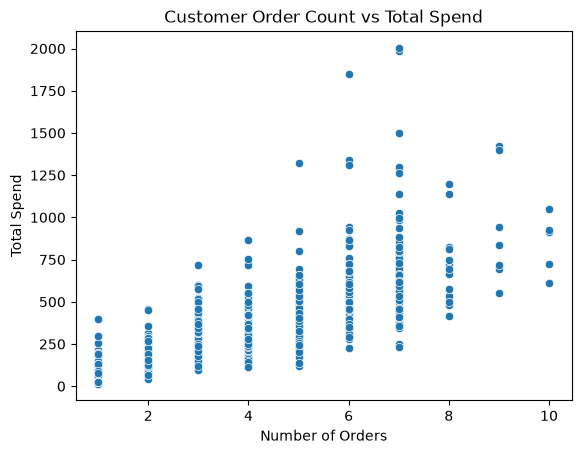

In [36]:
sns.scatterplot(data=customer_analysis, x="order_count", y="total_spend")
plt.title("Customer Order Count vs Total Spend")
plt.xlabel("Number of Orders")
plt.ylabel("Total Spend")
plt.show()

### Association Interpretation

The correlation between customer order count and total spend is 0.767, indicating a positive association. Customers with more orders generally tend to have higher total spending.

However, correlation does not establish causation. This result does not mean that increasing a customer's number of orders will necessarily cause their total spending to increase. Other factors, such as order value, products purchased, and discounts, may also contribute to the relationship.

Hypothesis Test 1: Houston Churn vs Everyone Else

In [39]:
houston = customers_clean[customers_clean["city"] == "Houston"]
other_cities = customers_clean[customers_clean["city"] != "Houston"]
print("Houston customers:", len(houston))
print("Houston churn rate:", houston["churned"].mean())

print("Other-city customers:", len(other_cities))
print("Other-city churn rate:", other_cities["churned"].mean())

Houston customers: 188
Houston churn rate: 0.30319148936170215
Other-city customers: 662
Other-city churn rate: 0.1268882175226586


Two-Proportion Test

In [40]:
from scipy.stats import norm
n_houston = len(houston)
n_other = len(other_cities)

x_houston = houston["churned"].sum()
x_other = other_cities["churned"].sum()

p_houston = x_houston / n_houston
p_other = x_other / n_other
p_pooled = (x_houston + x_other) / (n_houston + n_other)

# Standard error under H0
se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_houston + 1 / n_other))

# Z statistic
z_stat = (p_houston - p_other) / se

# Two-sided p-value
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("Houston churn rate:", round(p_houston * 100, 2), "%")
print("Other-city churn rate:", round(p_other * 100, 2), "%")
print("Difference:", round((p_houston - p_other) * 100, 2), "percentage points")
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)

Houston churn rate: 30.32 %
Other-city churn rate: 12.69 %
Difference: 17.63 percentage points
Z-statistic: 5.7352
P-value: 9.742381346100615e-09


### Interpretation

**Null hypothesis:** Houston and other cities have the same churn rate.

**Test used:** Two-proportion z-test.

**Result:** Houston churn rate = 30.32%, compared with 12.69% for other cities.

**P-value:** 9.74 × 10⁻⁹

Since the p-value is below 0.05, we reject the null hypothesis. There is strong statistical evidence that the observed Houston churn rate differs from the churn rate in other cities.

**Manager takeaway:** Houston has a substantially higher observed churn rate. Further investigation could focus on customer experience, support issues, and differences in product mix. This test shows an association, not causation.

Hypothesis Test 2: Kitchen Return Rate vs Other Categories

In [41]:
# Join orders with product category
orders_with_category = orders_clean.merge(products[["product_id", "category"]], on="product_id", how="left")
kitchen = orders_with_category[orders_with_category["category"] == "Kitchen"]
other_categories = orders_with_category[orders_with_category["category"] != "Kitchen"]
print("Kitchen orders:", len(kitchen))
print("Kitchen return rate:", kitchen["returned"].mean())

print("Other-category orders:", len(other_categories))
print("Other-category return rate:", other_categories["returned"].mean())

Kitchen orders: 713
Kitchen return rate: 0.23842917251051893
Other-category orders: 2650
Other-category return rate: 0.0649056603773585


In [42]:
# Number of orders in each group
n_kitchen = len(kitchen)
n_other = len(other_categories)

# Number of returned orders
x_kitchen = kitchen["returned"].sum()
x_other = other_categories["returned"].sum()

# Sample return rates
p_kitchen = x_kitchen / n_kitchen
p_other = x_other / n_other

# Pooled proportion under H0
p_pooled = (x_kitchen + x_other) / (n_kitchen + n_other)

# Standard error under H0
se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_kitchen + 1 / n_other))

# Z statistic
z_stat = (p_kitchen - p_other) / se

# Two-sided p-value
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("Kitchen return rate:", round(p_kitchen * 100, 2), "%")
print("Other-category return rate:", round(p_other * 100, 2), "%")
print("Difference:", round((p_kitchen - p_other) * 100, 2), "percentage points")
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value)

Kitchen return rate: 23.84 %
Other-category return rate: 6.49 %
Difference: 17.35 percentage points
Z-statistic: 13.6082
P-value: 0.0


### Interpretation

**Null hypothesis:** Kitchen and other product categories have the same return rate.

**Test used:** Two-proportion z-test.

**Result:** Kitchen return rate = 23.84%, compared with 6.49% for other categories.

**P-value:** < 0.001

Since the p-value is below 0.05, we reject the null hypothesis. There is strong statistical evidence that the observed Kitchen return rate differs from the return rate of other categories.

**Manager takeaway:** Kitchen products have a substantially higher observed return rate. Further investigation could focus on product quality, customer expectations, product descriptions, and operational issues. This test shows an association, not causation.

Station D — Features and Supervised Models

Building Customer-Level Features

In [43]:
customer_features = customers_clean.copy()

# Convert dates to datetime
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"])
support_tickets["created_at"] = pd.to_datetime(support_tickets["created_at"])
cutoff_date = pd.Timestamp("2026-06-01")

# Keep only orders available before the cutoff date
orders_before_cutoff = orders_clean[
    orders_clean["order_date"] < cutoff_date
].copy()

order_features = (
    orders_before_cutoff
    .groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max"),
        order_count=("order_id", "count"),
        total_spend=("order_value", "sum"),
        return_count=("returned", "sum")
    )
    .reset_index()
)

order_features["recency_days"] = (
    cutoff_date - order_features["last_order_date"]
).dt.days

order_features["return_rate"] = (
    order_features["return_count"]
    / order_features["order_count"]
)

# Support ticket count before cutoff
tickets_before_cutoff = support_tickets[
    support_tickets["created_at"] < cutoff_date
].copy()

ticket_features = (
    tickets_before_cutoff
    .groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)

customer_features = customer_features.merge(
    order_features[
        [
            "customer_id",
            "order_count",
            "total_spend",
            "recency_days",
            "return_rate"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_features = customer_features.merge(
    ticket_features,
    on="customer_id",
    how="left"
)

# Customers with no orders/tickets before cutoff get zero values
customer_features[
    ["order_count", "total_spend", "return_rate", "ticket_count"]
] = customer_features[
    ["order_count", "total_spend", "return_rate", "ticket_count"]
].fillna(0)

customer_features.head()

,customer_id,first_name,last_name,email,phone,city,state,signup_date,plan,age,last_active_date,churned,order_count,total_spend,recency_days,return_rate,ticket_count
0,10001,Ryan,Diaz,ryan.diaz1@gmail.com,+1-898-412-8529,Boston,MA,2025-02-05,free,42.0,2026-08-18,0,3.0,105.75,95.0,0.000000,0.0
1,10002,Maya,Brooks,maya.brooks2@yahoo.com,+1-629-420-1441,Chicago,IL,2025-03-12,plus,36.0,2026-08-21,0,6.0,924.20,162.0,0.500000,0.0
2,10003,Maya,Bennett,maya.bennett3@outlook.com,+1-445-842-4470,Austin,TX,2025-10-14,pro,41.0,2026-08-24,0,2.0,82.65,119.0,0.000000,2.0
3,10004,Arjun,Walker,arjun.walker4@gmail.com,+1-547-976-1578,Houston,TX,2025-11-28,free,18.0,2026-08-25,0,6.0,1074.00,8.0,0.166667,0.0
4,10005,Grace,Foster,grace.foster5@yahoo.com,+1-944-717-5118,Chicago,IL,2025-02-20,free,38.0,2026-08-30,0,4.0,864.05,7.0,0.500000,0.0


In [44]:
customer_features.shape

(850, 17)

In [45]:
customer_features[
    [
        "order_count",
        "total_spend",
        "recency_days",
        "return_rate",
        "ticket_count",
        "plan",
        "city",
        "churned"
    ]
].isnull().sum()

order_count      0
total_spend      0
recency_days    31
return_rate      0
ticket_count     0
plan             0
city             0
churned          0
dtype: int64

Handle missing recency

In [46]:
customer_features["recency_days"].describe()

count    819.000000
mean     108.885226
std      107.290566
min        1.000000
25%       29.000000
50%       74.000000
75%      150.500000
max      503.000000
Name: recency_days, dtype: float64

In [47]:
# Fill missing recency with one day beyond the maximum observed value
customer_features["recency_days"] = (customer_features["recency_days"].fillna(504))
print("Missing recency values:", customer_features["recency_days"].isna().sum())
print("Maximum recency:", customer_features["recency_days"].max())

Missing recency values: 0
Maximum recency: 504.0


In [48]:
customer_features[
    [
        "customer_id",
        "order_count",
        "total_spend",
        "recency_days",
        "return_rate",
        "ticket_count",
        "plan",
        "city",
        "churned"
    ]
].isnull().sum()

customer_id     0
order_count     0
total_spend     0
recency_days    0
return_rate     0
ticket_count    0
plan            0
city            0
churned         0
dtype: int64

Preparing Features and Target

In [49]:
# Select features that can be known at the cutoff date
feature_columns = [
    "order_count",
    "total_spend",
    "recency_days",
    "return_rate",
    "ticket_count",
    "plan",
    "city"
]

X = customer_features[feature_columns].copy()
y = customer_features["churned"].copy()

print("Features used:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features used:
['order_count', 'total_spend', 'recency_days', 'return_rate', 'ticket_count', 'plan', 'city']

Target distribution:
churned
0    709
1    141
Name: count, dtype: int64


In [50]:
X.head()

,order_count,total_spend,recency_days,return_rate,ticket_count,plan,city
0,3.0,105.75,95.0,0.000000,0.0,free,Boston
1,6.0,924.20,162.0,0.500000,0.0,plus,Chicago
2,2.0,82.65,119.0,0.000000,2.0,pro,Austin
3,6.0,1074.00,8.0,0.166667,0.0,free,Houston
4,4.0,864.05,7.0,0.500000,0.0,free,Chicago


In [51]:
y.value_counts()

churned
0    709
1    141
Name: count, dtype: int64

Train/Test Split and Feature Encoding

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ["order_count", "total_spend", "recency_days", "return_rate", "ticket_count"]
categorical_features = [ "plan", "city"]
preprocessor = ColumnTransformer(
    transformers=[("categorical",  OneHotEncoder(handle_unknown="ignore"), categorical_features)],
    remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training churned:", y_train.sum())
print("Testing churned:", y_test.sum())

Training rows: 680
Testing rows: 170
Training churned: 113
Testing churned: 28


Baseline Model

In [55]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

baseline_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", DummyClassifier(strategy="most_frequent"))])
baseline_model.fit(X_train, y_train)

# Predictions
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

# Evaluate
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_auc = roc_auc_score(y_test, baseline_prob)

print("Baseline Accuracy:", round(baseline_accuracy, 3))
print("Baseline Precision:", round(baseline_precision, 3))
print("Baseline Recall:", round(baseline_recall, 3))
print("Baseline ROC-AUC:", round(baseline_auc, 3))

Baseline Accuracy: 0.835
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline ROC-AUC: 0.5


Logistic Regression Model

In [56]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

# Predictions
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

# Evaluate the model
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(
    y_test, logistic_pred, zero_division=0
)
logistic_recall = recall_score(
    y_test, logistic_pred, zero_division=0
)
logistic_auc = roc_auc_score(y_test, logistic_prob)

print("Logistic Regression Accuracy:", round(logistic_accuracy, 3))
print("Logistic Regression Precision:", round(logistic_precision, 3))
print("Logistic Regression Recall:", round(logistic_recall, 3))
print("Logistic Regression ROC-AUC:", round(logistic_auc, 3))

Logistic Regression Accuracy: 0.847
Logistic Regression Precision: 0.556
Logistic Regression Recall: 0.357
Logistic Regression ROC-AUC: 0.786


Error Analysis

In [57]:
test_results = X_test.copy()
test_results["actual_churn"] = y_test
test_results["predicted_churn"] = logistic_pred

# Identify false negatives
false_negatives = test_results[
    (test_results["actual_churn"] == 1) &
    (test_results["predicted_churn"] == 0)
].copy()

print("False negatives:", len(false_negatives))
print("\nFalse negative profile:")
print(
    false_negatives[
        [
            "order_count",
            "total_spend",
            "recency_days",
            "return_rate",
            "ticket_count",
            "plan",
            "city"
        ]
    ].describe(include="all")
)

False negatives: 18

False negative profile:
        order_count  total_spend  recency_days  return_rate  ticket_count  \
count     18.000000    18.000000     18.000000    18.000000     18.000000   
unique          NaN          NaN           NaN          NaN           NaN   
top             NaN          NaN           NaN          NaN           NaN   
freq            NaN          NaN           NaN          NaN           NaN   
mean       2.333333   200.150000    203.111111     0.228704      0.388889   
std        1.414214   189.752457    105.637498     0.332833      0.607685   
min        1.000000    15.000000      3.000000     0.000000      0.000000   
25%        1.000000    56.500000    141.500000     0.000000      0.000000   
50%        2.000000   110.500000    212.500000     0.000000      0.000000   
75%        3.750000   345.150000    250.750000     0.333333      1.000000   
max        5.000000   728.650000    419.000000     1.000000      2.000000   

        plan    city  
count  

### Error Analysis

The model missed 18 customers who actually churned.

These false negatives generally had relatively low order activity, with an average of 2.33 orders and average total spend of 200.15. Their average recency was 203 days, indicating that many had not ordered recently. Most of the missed churned customers were on the free plan (13 out of 18).

The missed customers were spread across 9 cities, so the errors were not concentrated in a single location.

**Manager takeaway:** The model may miss some low-activity customers who have already become inactive. These customers could still be considered for retention outreach, especially customers with long recency and low order frequency.